<a href="https://colab.research.google.com/github/chayan141/ML-DL-Projects/blob/main/Extensive_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

# 2D tensor (2x3)
a = tf.constant([[1, 2, 3],
                 [4, 5, 6]])
a

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[1, 2, 3],
       [4, 5, 6]], dtype=int32)>

In [2]:
# Reshape to 3x2
b = tf.reshape(a, [3, 2])
print(b)

tf.Tensor(
[[1 2]
 [3 4]
 [5 6]], shape=(3, 2), dtype=int32)


In [5]:
# 2D tensor (2x4)
a = tf.constant([[1, 2, 3, 4],
                 [5, 6, 7, 8]])
# Reshape to 4x? (let TensorFlow infer the second dimension)
b = tf.reshape(a, [4, -1])
print(b)
# Output:
# [[1 2]
#  [3 4]
#  [5 6]
#  [7 8]]

tf.Tensor(
[[1 2]
 [3 4]
 [5 6]
 [7 8]], shape=(4, 2), dtype=int32)


In [6]:
# 1D tensor with 12 elements
a = tf.constant([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
# Reshape to 2x3x2
# b = tf.reshape(a, [2, 3, 2])
# print(b)
# Output:
# [[[ 1  2]
#   [ 3  4]
#   [ 5  6]]
#  [[ 7  8]
#   [ 9 10]
#   [11 12]]]

In [7]:
a.shape

TensorShape([12])

In [8]:
b = tf.reshape(a, [2, 3, 2])
print(b)

tf.Tensor(
[[[ 1  2]
  [ 3  4]
  [ 5  6]]

 [[ 7  8]
  [ 9 10]
  [11 12]]], shape=(2, 3, 2), dtype=int32)


Tensorflow to Numpy

In [9]:
import tensorflow as tf
import numpy as np

# Create a TensorFlow tensor
tensor = tf.constant([[1, 2], [3, 4]])
# Convert to NumPy array
numpy_array = tensor.numpy()
print(numpy_array)
# Output: [[1 2]
#          [3 4]]
print(type(numpy_array))  # Output: <class 'numpy.ndarray'>

[[1 2]
 [3 4]]
<class 'numpy.ndarray'>


Numpy to Tensorflow

In [10]:
# Create a NumPy array
numpy_array = np.array([[1, 2], [3, 4]])
# Convert to TensorFlow tensor
tensor = tf.convert_to_tensor(numpy_array)
print(tensor)
# Output: tf.Tensor([[1 2]
#                    [3 4]], shape=(2, 2), dtype=int64)
print(type(tensor))  # Output: <class 'tensorflow.python.framework.ops.EagerTensor'>

tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int64)
<class 'tensorflow.python.framework.ops.EagerTensor'>


In [11]:
tensor = tf.constant([[1, 2], [3, 4]])
numpy_array = tensor.numpy()
result = np.linalg.eigvals(numpy_array)  # NumPy-specific operation
print(result)

[-0.37228132  5.37228132]


Tensorflow to numpy : During Plotting, Dataframe creation

# ANN for classification using Keras

In [12]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load Iris dataset
iris = load_iris()
X = iris.data  # Features: (150 samples, 4 features)
y = iris.target  # Labels: (150 samples,)

For multiclass classification, convert categorical labels to one-hot encoded format using OneHotEncoder or to_categorical (Keras utility).

There is an alternative loss function in Keras called sparse_categorical_crossentropy which does accept integer-encoded labels directly with a softmax output. However, categorical_crossentropy with one-hot encoded labels is also very common and often used, as seen in your notebook setup.

For multiclass classification using ANN, one-hot encoding ensures the output layer matches the number of classes.

In [13]:
from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y = to_categorical(y)  # Shape: (150, 3) for 3 classes

In [15]:
y.shape

(150, 3)

In [16]:
# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)  # Shape: (150, 4)
X.shape

(150, 4)

Train-Test Split: Ensures the model is evaluated on unseen data to assess generalization.

In [17]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Shapes: X_train (120, 4), y_train (120, 3), X_test (30, 4), y_test (30, 3)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create a Sequential model
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),  # Hidden layer 1: 16 neurons
    Dense(8, activation='relu'),                    # Hidden layer 2: 8 neurons
    Dense(3, activation='softmax')                  # Output layer: 3 classes
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # For multiclass classification
              metrics=['accuracy'])

Loss: categorical_crossentropy is used for multiclass classification with one-hot encoded labels.

In [20]:
# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,          # Number of training iterations
                    batch_size=16,     # Number of samples per gradient update
                    validation_split=0.2,  # Use 20% of training data for validation
                    verbose=1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.0680 - loss: 1.3523 - val_accuracy: 0.0417 - val_loss: 1.4292
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0750 - loss: 1.3262 - val_accuracy: 0.1250 - val_loss: 1.3704
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1164 - loss: 1.2733 - val_accuracy: 0.1667 - val_loss: 1.3171
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2088 - loss: 1.2396 - val_accuracy: 0.2500 - val_loss: 1.2691
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3655 - loss: 1.1311 - val_accuracy: 0.2917 - val_loss: 1.2289
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5180 - loss: 1.0979 - val_accuracy: 0.3750 - val_loss: 1.1910
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5576 - loss: 1.0891 - val_accuracy: 0.3750 - val_loss: 1.1545
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6466 - loss: 1.0186 - val_accuracy: 0.4167 - val_loss: 1.1219


Batch Size: Number of samples processed before updating weights (e.g., 16). Smaller batches can lead to noisier but more robust updates.

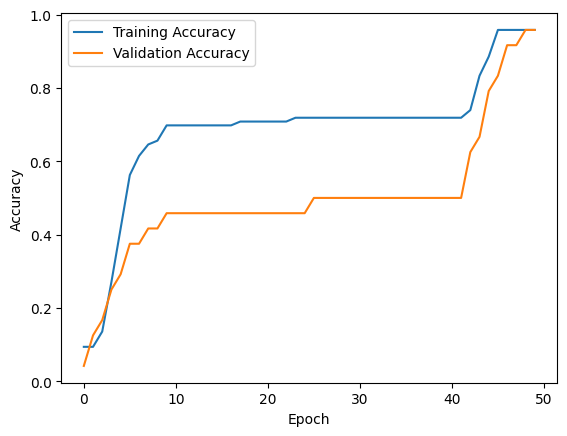

In [21]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Overfitting: If validation accuracy plateaus or decreases while training accuracy increases, the model may be overfitting. Consider regularization (e.g., Dropout) or early stopping.

Use Early Stopping to stop training when validation loss stops imporving.

For Iris (3 classes), the output layer has 3 neurons with softmax, producing a shape of (batch_size, 3) with probabilities summing to 1.

For images or other data, reshape inputs accordingly (e.g., (height, width, channels) for images).

Cross-validation assesses the model’s generalization by training and evaluating it on multiple subsets of the data. Keras doesn’t natively support cross-validation, so we use scikit-learn’s KFold.

In [22]:
from sklearn.model_selection import KFold

# Define K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

# Convert one-hot encoded y back to labels for K-Fold
y_labels = np.argmax(y, axis=1)

# Iterate over folds
for train_idx, val_idx in kfold.split(X):
    # Split data
    X_train_cv, X_val_cv = X[train_idx], X[val_idx]
    y_train_cv, y_val_cv = y[train_idx], y[val_idx]

    # Build model
    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train model
    model.fit(X_train_cv, y_train_cv, epochs=50, batch_size=16, verbose=0)

    # Evaluate on validation fold
    _, accuracy = model.evaluate(X_val_cv, y_val_cv, verbose=0)
    accuracies.append(accuracy)

print(f"Cross-Validation Accuracies: {accuracies}")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Cross-Validation Accuracies: [0.9666666388511658, 0.8999999761581421, 0.9333333373069763, 0.8999999761581421, 0.9333333373069763]
Mean Accuracy: 0.9267


KFold: Splits data into k folds (e.g., 5), training on k-1 folds and validating on the remaining fold.

Cross validation helps better generalization by reducing bias from train test split.

Implementation: Rebuild and train the model for each fold to avoid data leakage.

Stratified K-fold: For imbalanced class data, use stratified k-fold cross validation to maintain class distribution for each fold.

In [23]:
# Simulate new data (e.g., one sample with 4 features)
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example iris sample
new_data = scaler.transform(new_data)  # Apply same scaling as training data

In [24]:
# Predict class probabilities
predictions = model.predict(new_data)
print(predictions)  # Output: [[0.95, 0.04, 0.01]] (probabilities for 3 classes)

# Get predicted class
predicted_class = np.argmax(predictions, axis=1)
print(f"Predicted Class: {iris.target_names[predicted_class[0]]}")  # Output: setosa

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[[0.9904038  0.00835385 0.00124239]]
Predicted Class: setosa


In [25]:
predicted_class

array([0])

# Tensorboard

TensorBoard is a visualization tool provided with TensorFlow to monitor, analyze, and debug machine learning models. It allows you to visualize metrics (e.g., loss, accuracy), model graphs, histograms of weights/biases, embeddings, and more during training.

Key Features of tensorboard :

Plot metrices like loss and accuracy over epochs.

Vizualize the computational graph of the model.

Display the distributions of weights, biases and activation

View images (e.g., input data or generated outputs).

Visualize high-dimensional data in 2D/3D (e.g., word embeddings).

Analyze performance and resource usage.


Early Stopping : Use tf.keras.callbacks.EarlyStopping with parameters like patience (number of epochs to wait before stopping) and restore_best_weights (to revert to the best model weights).

Batch Normalization: Normalizes the activations of each layer within a mini-batch, stabilizing and accelerating training by reducing internal covariate shift.

Add BatchNormalization layers after Dense layers (before activation) to normalize inputs to the next layer.

Dropout: Randomly sets a fraction of input units to 0 during training to prevent overfitting by reducing reliance on specific neurons.

Add Dropout layers with a dropout rate (e.g., 0.3) after hidden layers.

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import datetime
import matplotlib.pyplot as plt

# Step 1: Data Preprocessing
iris = load_iris()
X, y = iris.data, iris.target
y = to_categorical(y)  # One-hot encode labels
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Step 2: Model Building with Batch Normalization and Dropout
model = Sequential([
    Dense(16, input_shape=(4,)),  # Input layer
    BatchNormalization(),         # Normalize activations
    tf.keras.layers.Activation('relu'),  # Apply ReLU after BatchNorm
    Dropout(0.3),                # 30% dropout
    Dense(8),                    # Second hidden layer
    BatchNormalization(),         # Normalize activations
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),                # 30% dropout
    Dense(3, activation='softmax')  # Output layer
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339 (1.32 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 48 (192.00 B)

In [28]:
#  Step 3: Set up Callbacks (TensorBoard and Early Stopping)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq='epoch'
)

In [29]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop after 10 epochs of no improvement
    restore_best_weights=True  # Revert to best weights
)

In [30]:
# Step 4: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,  # Increased epochs, early stopping will halt if needed
    batch_size=16,
    validation_split=0.2,
    callbacks=[tensorboard_callback, early_stopping],
    verbose=1
)


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 240ms/step - accuracy: 0.5043 - loss: 0.9885 - val_accuracy: 0.5000 - val_loss: 0.8672
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4746 - loss: 1.1081 - val_accuracy: 0.5833 - val_loss: 0.8491
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.5766 - loss: 0.8764 - val_accuracy: 0.6250 - val_loss: 0.8306
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5339 - loss: 0.9422 - val_accuracy: 0.7083 - val_loss: 0.8114
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5289 - loss: 0.9070 - val_accuracy: 0.7500 - val_loss: 0.7945
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.6926 - loss: 0.7177 - val_accuracy: 0.7500 - val_loss: 0.7764
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.6320 - loss: 0.8130 - val_accuracy: 0.7500 - val_loss: 0.7600
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6225 - loss: 0.8281 - val_accuracy: 0.7500 - val_loss

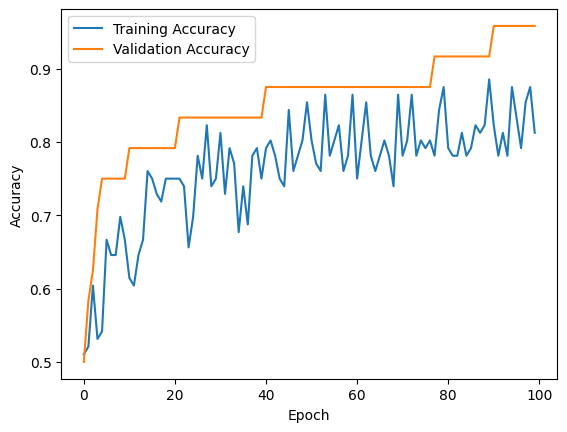

In [31]:
# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [32]:
# Step 5: Evaluate on Test Set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9333 - loss: 0.2265
Test Accuracy: 0.9333


In [33]:
with tf.summary.create_file_writer(log_dir).as_default():
    tf.summary.scalar('test_accuracy', test_accuracy, step=1)

In [34]:
# Step 6: Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
y_labels = np.argmax(y, axis=1)
for train_idx, val_idx in kfold.split(X):
    X_train_cv, X_val_cv = X[train_idx], X[val_idx]
    y_train_cv, y_val_cv = y[train_idx], y[val_idx]
    model_cv = Sequential([
        Dense(16, input_shape=(4,)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),
        Dense(8),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ])
    model_cv.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model_cv.fit(
        X_train_cv, y_train_cv,
        epochs=50,
        batch_size=16,
        callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    _, accuracy = model_cv.evaluate(X_val_cv, y_val_cv, verbose=0)
    accuracies.append(accuracy)
print(f"Cross-Validation Accuracies: {accuracies}")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Cross-Validation Accuracies: [0.9333333373069763, 0.800000011920929, 0.9333333373069763, 0.9333333373069763, 0.9333333373069763]
Mean Accuracy: 0.9067


In [35]:
# Step 7: Prediction with New Data
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example sample
new_data = scaler.transform(new_data)  # Apply same scaling
predictions = model.predict(new_data)
predicted_class = np.argmax(predictions, axis=1)
print(f"Predicted Class: {iris.target_names[predicted_class[0]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Predicted Class: setosa


# Regularization

To Remove Overfitting

L1 (Lasso): Adds the sum of absolute weights to the loss function, encouraging sparsity (some weights become zero).

L2 (Ridge): Adds the sum of squared weights, encouraging smaller weights overall.

Effect: Penalizes large weights, reducing model complexity and sensitivity to noise.

Weight Constraints : Limit the magnitude of weights (ensures the weights dont exceed a threshold).

Effect: Prevents weights from growing too large, similar to L2 regularization but enforced directly.

In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from tensorflow.keras import regularizers, constraints
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import datetime
import matplotlib.pyplot as plt

# Step 1: Data Preprocessing
iris = load_iris()
X, y = iris.data, iris.target
y = to_categorical(y)  # One-hot encode labels
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# Step 2: Model Building with Regularization
model = Sequential([
    Dense(16, input_shape=(4,),
          kernel_regularizer=regularizers.l2(0.01),  # L2 regularization
          kernel_constraint=constraints.max_norm(3.0)),  # Max-norm constraint
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),
    Dense(8,
          kernel_regularizer=regularizers.l1(0.01),  # L1 regularization
          kernel_constraint=constraints.max_norm(3.0)),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339 (1.32 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 48 (192.00 B)

In [38]:
# Step 3: Set up Callbacks (TensorBoard and Early Stopping)
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq='epoch'
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.5378 - loss: 1.3869 - val_accuracy: 0.7917 - val_loss: 1.2559
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.5244 - loss: 1.4236 - val_accuracy: 0.8333 - val_loss: 1.2349
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5295 - loss: 1.4541 - val_accuracy: 0.7917 - val_loss: 1.2149
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4938 - loss: 1.4570 - val_accuracy: 0.7917 - val_loss: 1.1959
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5539 - loss: 1.2841 - val_accuracy: 0.7917 - val_loss: 1.1762
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.6446 - loss: 1.2864 - val_accuracy: 0.7917 - val_loss: 1.1587
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.4920 - loss: 1.4518 - val_accuracy: 0.7917 - val_loss: 1.1429
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.6554 - loss: 1.2032 - val_accuracy: 0.7917 - val_loss: 1.

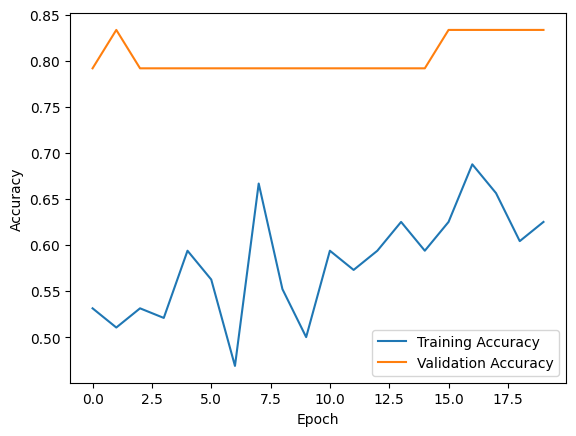

In [39]:
# Step 4: Train Model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    callbacks=[tensorboard_callback, early_stopping],
    verbose=1
)

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [40]:
# Step 5: Evaluate on Test Set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Log test accuracy to TensorBoard
with tf.summary.create_file_writer(log_dir).as_default():
    tf.summary.scalar('test_accuracy', test_accuracy, step=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8667 - loss: 0.9606
Test Accuracy: 0.8667


In [41]:
# Step 6: Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
y_labels = np.argmax(y, axis=1)
for train_idx, val_idx in kfold.split(X):
    X_train_cv, X_val_cv = X[train_idx], X[val_idx]
    y_train_cv, y_val_cv = y[train_idx], y[val_idx]
    model_cv = Sequential([
        Dense(16, input_shape=(4,),
              kernel_regularizer=regularizers.l2(0.01),
              kernel_constraint=constraints.max_norm(3.0)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),
        Dense(8,
              kernel_regularizer=regularizers.l1(0.01),
              kernel_constraint=constraints.max_norm(3.0)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ])
    model_cv.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model_cv.fit(
        X_train_cv, y_train_cv,
        epochs=30,
        batch_size=16,
        callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    _, accuracy = model_cv.evaluate(X_val_cv, y_val_cv, verbose=0)
    accuracies.append(accuracy)
print(f"Cross-Validation Accuracies: {accuracies}")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}")

# Step 7: Prediction with New Data
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example sample
new_data = scaler.transform(new_data)
predictions = model.predict(new_data)
predicted_class = np.argmax(predictions, axis=1)
print(f"Predicted Class: {iris.target_names[predicted_class[0]]}")




/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Cross-Validation Accuracies: [0.9333333373069763, 0.7666666507720947, 0.8333333134651184, 0.7666666507720947, 0.6666666865348816]
Mean Accuracy: 0.7933
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Predicted Class: setosa


If my training accuracy is not increasing but bvalidation accuracy increases, them model must have exxcessive regularization.

Model could not able to learn complex patterns, You force model to exessive regularization.

# Hyperparameter Tuning

Unlike model parameters (i.e. weights or biases), they are learnt during training, but hyperparameters are configuration settings defined before training that control the learning process or model architechture.

Finding out the best combinations of hyperparameters to achieve optimal performance, often evaluated on validation set.

Hyperparameters: No of layers, No of neurons per layers, Regularization strength, dropout rate, learning rate, batch size, number of epochs, optimizers,

Grid Search CV: Systemetic evaluation of all possible combinations of a predefined set of hyperparameter values. For each conbination, the model is trained and evaluated via cross validation.

tf_keras.wrappers.scikit_learn import KerasClassifier

In [49]:
!pip install --upgrade scikit-learn scikeras --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 34.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.0 which is incompatible.


In [50]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier # Corrected import

def create_model(learning_rate=0.001, neurons1=16, neurons2=8, dropout_rate=0.1):
    model = Sequential([
        Dense(neurons1, input_shape=(4,), kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(dropout_rate),
        Dense(neurons2, kernel_regularizer=regularizers.l1(0.001)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(dropout_rate),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap Keras model for scikit-learn
model = KerasClassifier(model=create_model, verbose=0) # Use model instead of build_fn

In [52]:
# # Define parameter grid
# param_grid = {
#     'learning_rate': [0.001, 0.01, 0.1],
#     'neurons1': [16, 32, 64],
#     'neurons2': [8, 16, 32],
#     'dropout_rate': [0.1, 0.2, 0.3],
#     'batch_size': [16, 32],
#     'epochs': [50, 100]
# }

# # Perform grid search with cross-validation
# grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, verbose=1)
# grid_result = grid.fit(X_train, y_train)

# # Print best parameters and score
# print("Best Parameters:", grid_result.best_params_)
# print("Best Accuracy:", grid_result.best_score_)

RandomSearchCV : Randomly samples hyperparameter combinations from a defined range or distribution,

In [53]:
!pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.4 MB/s eta 0:00:00


In [55]:
import keras_tuner as kt

def build_model(hp):
    model = Sequential([
        Dense(units=hp.Int('neurons1', min_value=16, max_value=64, step=16),
              input_shape=(4,), kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(hp.Float('dropout_rate', min_value=0.1, max_value=0.3, step=0.1)),
        Dense(units=hp.Int('neurons2', min_value=8, max_value=32, step=8),
              kernel_regularizer=regularizers.l1(0.001)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(hp.Float('dropout_rate', min_value=0.1, max_value=0.3, step=0.1)),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(
        hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Initialize RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=1,  # Number of combinations to try
    directory='tuner_logs',
    project_name='iris_tuning'
)

# Search for best hyperparameters
tuner.search(X_train, y_train, epochs=50, validation_split=0.2, batch_size=32)
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters()[0]

print("Best Hyperparameters:", best_hps.values)

Reloading Tuner from tuner_logs/iris_tuning/tuner0.json
Best Hyperparameters: {'neurons1': 64, 'dropout_rate': 0.1, 'neurons2': 8, 'learning_rate': 0.003866530565373367}


Basiyan Optimization: Uses a probabilistic model (e.g., Gaussian Process) to predict the performance of hyperparameter combinations and intelligently selects the next combination to evaluate, balancing exploration and exploitation.

It learns from the previous trails and converges towards the good solution by balancing exploration and exploitation.

In [56]:
tuner = kt.BayesianOptimization(
    build_model,  # Same build_model function as above
    objective='val_accuracy',
    max_trials=1,
    directory='tuner_logs',
    project_name='iris_bayesian'
)
tuner.search(X_train, y_train, epochs=50, validation_split=0.2, batch_size=32)
best_model = tuner.get_best_models(num_models=1)[0]
print("Best Hyperparameters:", tuner.get_best_hyperparameters()[0].values)

Trial 1 Complete [00h 00m 15s]
val_accuracy: 0.9583333134651184

Best val_accuracy So Far: 0.9583333134651184
Total elapsed time: 00h 00m 15s
Best Hyperparameters: {'neurons1': 32, 'dropout_rate': 0.2, 'neurons2': 8, 'learning_rate': 0.002056724845809137}


Hyperband: Combines random search with early stopping. It trains multiple models with different hyperparameter configuration for few epochs, the discard poorly performing ones, allocating more resources (epochs) to promising configurations.

In [57]:
# tuner = kt.Hyperband(
#     build_model,  # Same build_model function
#     objective='val_accuracy',
#     max_epochs=100,  # Maximum epochs per model
#     factor=3,  # Reduction factor for successive halving
#     directory='tuner_logs',
#     project_name='iris_hyperband'
# )
# tuner.search(X_train, y_train, validation_split=0.2, batch_size=32)
# best_model = tuner.get_best_models(num_models=1)[0]
# print("Best Hyperparameters:", tuner.get_best_hyperparameters()[0].values)

Trial 51 Complete [00h 00m 07s]
val_accuracy: 0.3333333432674408

Best val_accuracy So Far: 0.9166666865348816
Total elapsed time: 00h 05m 03s

Search: Running Trial #52

Value             |Best Value So Far |Hyperparameter
64                |48                |neurons1
0.1               |0.1               |dropout_rate
24                |8                 |neurons2
0.0056971         |0.006983          |learning_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
4                 |4                 |tuner/bracket
0                 |0                 |tuner/round



ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.


KeyboardInterrupt

